## 실습 문제: He 가중치 초기화 시뮬레이션

**설명**: 딥러닝에서 신경망의 가중치는 학습 시작 전에 무작위로 초기화됩니다. He 초기화는 ReLU 활성화 함수에 적합한 방법으로, 가중치를 평균 0, 표준편차 $\sqrt{2 / \text{입력 뉴런 수}}$의 정규 분포로 설정합니다. `np.random.normal()`을 사용해 He 초기화를 시뮬레이션하고, 가중치 분포를 Matplotlib으로 히스토그램으로 시각화해보세요.

$$\text{weight} \sim \mathcal{N}(0, \sqrt{2/n_{in}})$$

**요구사항**:

  - 입력 뉴런 수(`fan_in`)를 1000으로 설정하고, He 초기화 원칙에 따라 1000개의 가중치를 생성하세요. 표준편차는 $\sqrt{2 / \text{입력 뉴런 수}}$ 로 계산합니다. (`np.random.normal` 함수를 사용하세요.)
  - 생성된 1000개의 가중치를 Matplotlib을 사용하여 히스토그램으로 시각화하고, 그래프의 제목을 "He Initialization Weights"로 설정하세요.
  - 생성된 히스토그램이 평균 0을 중심으로 대칭적인 종 모양을 갖는지 확인하고, 가중치 분포의 특성을 파악하세요.

In [23]:
import numpy as np
import matplotlib.pyplot as plt

def he_init(fan_in: int) -> None:
    """
    He 초기화에 따라 가중치를 생성하고 히스토그램으로 시각화합니다.

    Args:
        fan_in (int): 입력 뉴런의 수.
    """
    result = np.random.normal(0,np.sqrt(2/fan_in), fan_in)
    return result



(array([  9.,  33., 112., 196., 279., 204., 123.,  34.,   8.,   2.]),
 array([-0.13402272, -0.10425591, -0.0744891 , -0.04472229, -0.01495548,
         0.01481133,  0.04457814,  0.07434495,  0.10411176,  0.13387857,
         0.16364538]),
 <BarContainer object of 10 artists>)

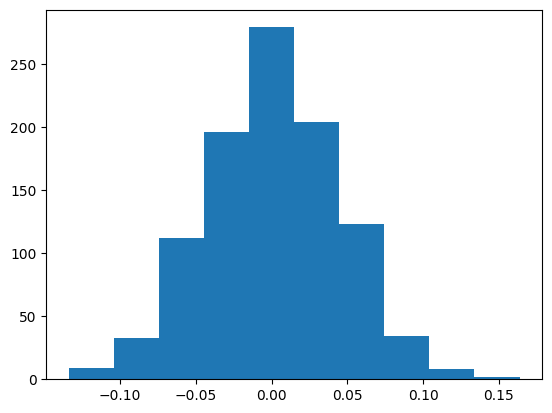

In [24]:
result = he_init(1000)

plt.hist(result)

## 실습 문제: 소프트맥스 함수 계산 및 시각화

**설명**:
소프트맥스(Softmax) 함수는 인공지능 모델이 출력하는 점수(score 또는 logit)를 각 클래스에 대한 확률 분포로 변환하는 핵심적인 요소입니다. 예를 들어, 모델이 어떤 이미지에 대해 [강아지 점수=3, 고양이 점수=1]이라는 결과를 냈다면, 소프트맥스는 이를 [강아지일 확률=0.88, 고양이일 확률=0.12]와 같이 변환하여 모든 클래스의 확률 총합이 1이 되도록 만듭니다.

이 실습에서는 '고양이' 점수를 고정한 채 '강아지' 점수를 변화시키면서, 점수 변화에 따른 '강아지'일 확률의 변화를 계산하고 그래프로 시각화하여 소프트맥스 함수의 특징을 직관적으로 이해해 봅니다.

$$\text{softmax}(z)_{i} = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}$$

**요구사항**:

1.  **입력 설정**: '강아지' 점수 `z_dog`를 `np.linspace(-5, 5, 100)`를 사용해 생성하고, '고양이' 점수 `z_cat`는 `1.0`으로 고정하세요.
2.  **함수 구현**: `softmax` 함수를 구현하여, 입력된 점수 배열 `z = [z_dog, z_cat]`에 대한 각 클래스의 확률을 계산하도록 만드세요. `np.exp()`를 사용하면 됩니다.
3.  **확률 계산**: `z_dog`의 각 점수에 대해 `softmax` 함수를 호출하여 '강아지일 확률'을 계산하고, 그 결과를 별도의 리스트에 저장하세요.
4.  **결과 시각화**: Matplotlib을 사용하여 x축은 '강아지 점수(`z_dog`)', y축은 '강아지일 확률'로 설정하여 2D 라인 그래프를 그리세요. 그래프의 제목과 축 레이블을 추가하여 결과를 명확하게 나타냅니다.


In [40]:
import numpy as np

logits = np.array([3,1,1])
np.exp(logits)

array([20.08553692,  2.71828183,  2.71828183])

In [41]:
np.exp(logits)/np.sum(np.exp(logits))

array([0.78698604, 0.10650698, 0.10650698])

In [ ]:
def softmax(logits: np.ndarray) -> np.ndarray:
    """
    입력된 로짓 배열에 대해 소프트맥스 확률을 계산합니다.

    Args:
        logits (np.ndarray): 모델의 원시 점수 배열.

    Returns:
        np.ndarray: 각 클래스에 대한 확률 배열.
    """
    e = np.exp(logits)
    s = np.sum(e)
    return e/s

In [ ]:
z_dog_scores = np.linspace(-5, 5, 100)
#z_cat_score = 1.0

softmax(z_dog_scores)

array([4.36202710e-06, 4.82565743e-06, 5.33856602e-06, 5.90599055e-06,
       6.53372539e-06, 7.22818079e-06, 7.99644834e-06, 8.84637337e-06,
       9.78663508e-06, 1.08268352e-05, 1.19775958e-05, 1.32506683e-05,
       1.46590529e-05, 1.62171317e-05, 1.79408152e-05, 1.98477052e-05,
       2.19572745e-05, 2.42910652e-05, 2.68729095e-05, 2.97291724e-05,
       3.28890212e-05, 3.63847234e-05, 4.02519762e-05, 4.45302709e-05,
       4.92632962e-05, 5.44993843e-05, 6.02920049e-05, 6.67003104e-05,
       7.37897408e-05, 8.16326912e-05, 9.03092517e-05, 9.99080248e-05,
       1.10527031e-04, 1.22274707e-04, 1.35271019e-04, 1.49648680e-04,
       1.65554512e-04, 1.83150939e-04, 2.02617653e-04, 2.24153440e-04,
       2.47978220e-04, 2.74335284e-04, 3.03493782e-04, 3.35751473e-04,
       3.71437764e-04, 4.10917073e-04, 4.54592551e-04, 5.02910201e-04,
       5.56363428e-04, 6.15498082e-04, 6.80918029e-04, 7.53291319e-04,
       8.33357009e-04, 9.21932705e-04, 1.01992292e-03, 1.12832830e-03,
      

In [46]:
import numpy as np


z_dog_scores = np.linspace(-5, 5, 100)
z_cat_score = np.ones(100)

logits = np.array(list(zip(z_dog_scores,z_cat_score)))


In [49]:
np.exp(logits).shape

(100, 2)

In [51]:
np.sum(logits,axis=1, keepdims=True).shape

(100, 1)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def softmax(logits: np.ndarray) -> np.ndarray:
    e = np.exp(logits)
    s = np.sum(logits,axis=1, keepdims=True)
    return e/s

In [53]:
z_dog_scores = np.linspace(-5, 5, 100)
z_cat_score = 1.0

softmax(z_dog_scores)

AxisError: axis 1 is out of bounds for array of dimension 1

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def softmax(logits: np.ndarray) -> np.ndarray:
    """
    입력된 로짓 배열에 대해 소프트맥스 확률을 계산합니다.

    Args:
        logits (np.ndarray): 모델의 원시 점수 배열.

    Returns:
        np.ndarray: 각 클래스에 대한 확률 배열.
    """

    return np.exp



## 실습 문제: ReLU 함수 구현 및 시각화

**설명**:
ReLU(Rectified Linear Unit) 함수, $f(x) = \max(0, x)$는 딥러닝에서 가장 널리 사용되는 활성화 함수 중 하나입니다. 입력값이 0보다 작으면 0을 반환하고, 0 이상이면 입력값을 그대로 반환하는 단순한 구조 덕분에 계산이 빠르고, 특정 조건에서 학습을 효율적으로 만듭니다. 이 실습에서는 NumPy와 Matplotlib을 사용하여 ReLU 함수의 동작을 직접 구현하고 그래프로 그려보겠습니다.

$$f(x) = \max(0, x)$$

**요구사항**:

  * `np.linspace()`를 사용하여 **x**의 범위를 -5부터 5까지 100개의 균일한 간격으로 생성하세요.
  * x의 각 원소에 ReLU 함수를 적용한 **y** 값을 계산하세요.
  * Matplotlib을 사용하여 **x**와 **y**를 기반으로 2D 라인 그래프를 그리세요.
  * 그래프의 제목은 "ReLU Function", x축 레이블은 "x", y축 레이블은 "f(x)"로 설정하고, 그리드를 추가하여 가독성을 높이세요.


In [8]:
import numpy as np
import matplotlib.pyplot as plt

def relu(x: np.ndarray) -> np.ndarray:
    """
    입력된 배열의 각 원소에 ReLU 함수를 적용합니다.

    Args:
        x (np.ndarray): 숫자들로 이루어진 NumPy 배열.

    Returns:
        np.ndarray: ReLU 함수가 적용된 결과 배열.
    """
    return [i if i>=0 else 0 for i in x ]


In [36]:
def relu(x: np.ndarray) -> np.ndarray:
    return np.maximum(x,0)

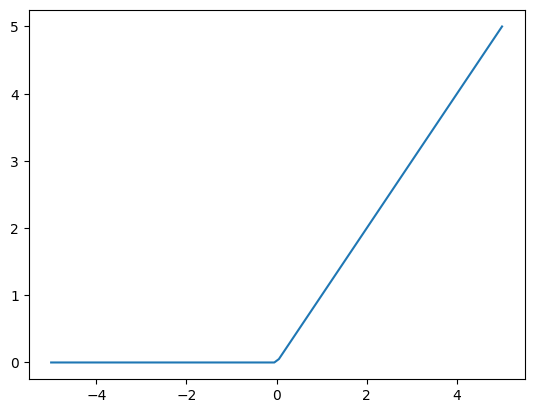

In [37]:
x_values = np.linspace(-5, 5, 100)
y_values = []
for x in x_values:
    y_values.append(relu(x))
plt.plot(x_values,y_values)


In [ ]:
def relu(x: np.ndarray) -> np.ndarray:
    return np.maximun(x,0)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, np.float64(0.050505050505050164), np.float64(0.15151515151515138), np.float64(0.2525252525252526), np.float64(0.3535353535353538), np.float64(0.45454545454545414), np.float64(0.5555555555555554), np.float64(0.6565656565656566), np.float64(0.7575757575757578), np.float64(0.8585858585858581), np.float64(0.9595959595959593), np.float64(1.0606060606060606), np.float64(1.1616161616161618), np.float64(1.262626262626262), np.float64(1.3636363636363633), np.float64(1.4646464646464645), np.float64(1.5656565656565657), np.float64(1.666666666666667), np.float64(1.7676767676767673), np.float64(1.8686868686868685), np.float64(1.9696969696969697), np.float64(2.070707070707071), np.float64(2.1717171717171713), np.float64(2.2727272727272725), np.float64(2.3737373737373737), np.float64(2.474747474747475), np.float64(2.5757575757575752), np.float64(2.6767

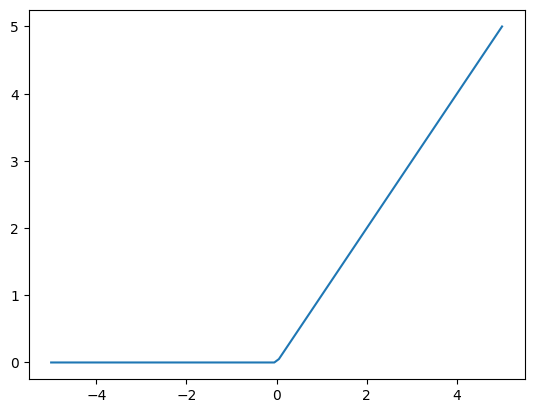

In [11]:

x_values = np.linspace(-5, 5, 100)
y_values = relu(x_values)
print(y_values)
plt.plot(x_values,y_values)


## 실습 문제: 시그모이드 함수 구현 및 시각화

**설명**:
시그모이드(Sigmoid) 함수는 로지스틱 함수라고도 불리며, 임의의 실수 입력값을 **0과 1 사이의 값으로 변환**하는 데 사용됩니다. 과거에는 인공 신경망의 활성화 함수나 로지스틱 회귀와 같은 모델에서 출력을 확률처럼 해석하기 위해 널리 사용되었습니다. 함수의 출력이 부드러운 **'S'자 형태**를 띠는 것이 특징입니다. 이 실습을 통해 시그모이드 함수를 직접 구현하고 그래프로 그려보겠습니다.

$$S(x) = \frac{1}{1 + e^{-x}}$$

**요구사항**:

  * `np.linspace()`를 사용하여 **x**의 범위를 -10부터 10까지 100개의 균일한 간격으로 생성하세요.
  * 위 수학 공식을 바탕으로, 입력 `x`에 대한 시그모이드 함수 값을 계산하는 `sigmoid_function`을 구현하세요. `np.exp()` 함수를 사용합니다.
  * Matplotlib을 사용하여 x값에 따른 시그모이드 함수 값을 라인 그래프로 그리세요. 그래프의 제목은 "Sigmoid Function", x축 레이블은 "x", y축 레이블은 "S(x)"로 설정합니다.
  * 그래프의 **y=0.5** 지점에 수평선(`axhline`)을 점선으로 추가하여, 입력이 0일 때 출력이 0.5가 되는 시그모이드 함수의 중심점을 시각적으로 확인하세요.

## MSE 함수

In [15]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x: np.ndarray) -> np.ndarray:
    """
    입력된 배열의 각 원소에 시그모이드 함수를 적용합니다.

    Args:
        x (np.ndarray): 숫자들로 이루어진 NumPy 배열.

    Returns:
        np.ndarray: 시그모이드 함수가 적용된 결과 배열.
    """
    return 1/(1+np.exp(-x))


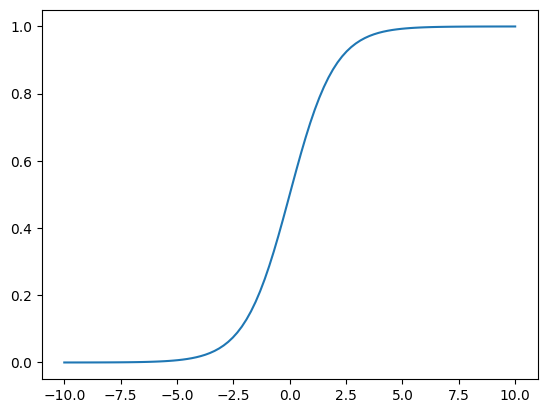

In [25]:
x_values = np.linspace(-10, 10, 100)
y_values = sigmoid(x_values)
#print(y_values)
plt.plot(x_values,y_values)